# DA3111 - Text Analytics - Group Assignment
## Group 01
1. 236005A - G. G. A. Adithya
2. 236024F - L. Y. G. E. De Silva
3. 236103X - G. K. M. A. Premarathna
4. 236107M - H. D. S. Ranasinghe
5. 236140G - H. T. S. S. Wickramarathna


## Section 01
## Task 01 - Preparing Data

### Import all the libraries required for Section 01

In [1]:
# Libraries for data preparation
import pandas as pd # to handle the dataframe
from IPython.display import display # to format the output of a cell
from wordcloud import WordCloud # for generating the wordcloud in EDA
import matplotlib.pyplot as plt # for EDA output formatting
from sklearn.feature_extraction.text import CountVectorizer
import re # regex library
import string # for common string operations

# Libraries for text preprocessing 
# import nltk library
import nltk # Natural Language Toolkit
from nltk.corpus import stopwords # import the stopwords from nltk library
# nltk.download('stopwords') # Download stop words list and storing it locally
from nltk.stem import PorterStemmer # stemming
from nltk.stem import WordNetLemmatizer # lemmatizing
from nltk.corpus import wordnet # to get the synsets of English words
# nltk.download('wordnet')
from collections import Counter # to get the count
from spellchecker import SpellChecker #to check spellings 


# Import the libraries required for finetuning 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import TrainingArguments, Trainer
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import EarlyStoppingCallback
from transformers import pipeline
from datasets import Dataset
import evaluate

from huggingface_hub import login
from huggingface_hub import notebook_login

In [2]:
#reading the excel files separately
business_df = pd.read_excel("Data/Data/Business.xlsx")
opinion_df = pd.read_excel("Data/Data/Opinion.xlsx")
political_df = pd.read_excel("Data/Data/Political_gossip.xlsx")
sports_df = pd.read_excel("Data/Data/Sports.xlsx")
world_df = pd.read_excel("Data/Data/World_news.xlsx")

In [3]:
# Initial glimpse of the excel files
# Glimpse of the Business News Excel file
print("Business News")
display(business_df.head(5))
display(business_df.info())

# Glimpse of the Personal Views Excel file
print("Personal Views")
display(opinion_df.head(5))
display(opinion_df.info())

# Glimpse of the Political News Excel file
print("Political News")
display(political_df.head(5))
display(political_df.info())

# Glimpse of the Sports News Excel file
print("Sports News")
display(sports_df.head(5))
display(sports_df.info()) 

# Glimpse of the International News Excel file
print("International News")
display(world_df.head(5))
display(world_df.info())        

Business News


,Unnamed: 0,title,content
0,0,"Inflation set to climb this year, expected to ...",Sri Lanka’s inflation is expected to increase ...
1,1,President Anura Kumara Dissanayake steers fina...,President Anura Kumara Dissanayake
2,2,From buzzword to bottom line: 5 key trends dri...,As artificial intelligence (AI) evolves from b...
3,3,Ride for Ceylon participants touch down in Col...,A group of Ride for Ceylon participants from t...
4,4,Week ends in green,The ASPI closed in green as a result of price ...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  210 non-null    int64 
 1   title       210 non-null    object
 2   content     208 non-null    object
dtypes: int64(1), object(2)
memory usage: 5.0+ KB


None

Personal Views


...

None

International News


,Unnamed: 0,title,content
0,0,"India, US to sign 10-year framework for Major ...",India and the US are set to begin talks to sig...
1,1,Bill to curb US investment in China to be rein...,Legislation to curb US investment in China wil...
2,2,Trump clears Mumbai terror attack accused Taha...,In a big announcement after his bilateral talk...
3,3,Adani’s global expansion faces scrutiny as com...,"Adani Green Energy, part of Indian billionaire..."
4,4,Chinese companies’ new tactic to stop damaging...,"A little over a year ago, a group of researche..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  210 non-null    int64 
 1   title       210 non-null    object
 2   content     210 non-null    object
dtypes: int64(1), object(2)
memory usage: 5.0+ KB


None

* From the above output, it is evident that the Business News, Personal Views and Political News excel files contain null records in the *content* column. Therefore, those records will be removed.
* Furthermore, the column *Unnamed: 0* will also be removed as it serves as a record ID which is not very important when proceeding with text analysis steps that are to come.
* A new column named *class* will be added to each excel file to identify the news category of each record which will be important when the excel files get combined.
* As specified in the guidelines the *title* column of each excel file will also be dropped.

In [4]:
# Business News
# Dropping title and Unnamed: 0 columns
business_df = business_df.drop(columns = ["title","Unnamed: 0"])

# Adding the class column
business_df["Class"] = "Business"

# drop duplicated records if any
business_df.drop_duplicates(keep="first", inplace=True)# any duplicates after the first occurance will be dropped

# drop null records
business_df.dropna(inplace=True)

# Viewing the updated dataset
business_df.head(5)

,content,Class
0,Sri Lanka’s inflation is expected to increase ...,Business
1,President Anura Kumara Dissanayake,Business
2,As artificial intelligence (AI) evolves from b...,Business
3,A group of Ride for Ceylon participants from t...,Business
4,The ASPI closed in green as a result of price ...,Business


In [5]:
# Opinion News
# Dropping title and Unnamed: 0 columns
opinion_df = opinion_df.drop(columns = ["title","Unnamed: 0"])

# Adding the class column
opinion_df["Class"] = "Opinion"

# drop duplicated records if any
opinion_df.drop_duplicates(keep="first", inplace=True)# any duplicates after the first occurance will be dropped

# drop null records
opinion_df.dropna(inplace=True)

# Viewing the updated dataset
opinion_df.head(5)

,content,Class
0,"Truth, the idiom goes is often stranger than f...",Opinion
1,A bizarre situation has arisen in the country ...,Opinion
2,The first part of this article published last ...,Opinion
3,"Every year, as winter arrives, thousands of mi...",Opinion
4,President Donald Trump first thought he could ...,Opinion


In [6]:
# Political News
# Dropping title and Unnamed: 0 columns
political_df = political_df.drop(columns = ["title","Unnamed: 0"])

# Adding the class column
political_df["Class"] = "Political"

# drop duplicated records if any
political_df.drop_duplicates(keep="first", inplace=True)# any duplicates after the first occurance will be dropped

# drop null records
political_df.dropna(inplace=True)

# Viewing the updated dataset
political_df.head(5)

,content,Class
0,Three to four Diyawanna members of a main poli...,Political
1,This politico once ran for the highest office ...,Political
2,There is a Top Team member elected to Diyawann...,Political
3,There is a taciturn Diyawanna politico who has...,Political
4,Having learnt that new governing ones were to ...,Political


In [7]:
# Sports News
# Dropping title and Unnamed: 0 columns
sports_df = sports_df.drop(columns = ["title","Unnamed: 0"])

# Adding the class column
sports_df["Class"] = "Sports"

# drop duplicated records if any
sports_df.drop_duplicates(keep="first", inplace=True)# any duplicates after the first occurance will be dropped

# No null records to be removed

# Viewing the updated dataset
sports_df.head(5)

,content,Class
0,"Former Sylvester’s, Kandy Sports Club and one ...",Sports
1,Sri Lanka take on Australia in two ODIs in Col...,Sports
2,Sri Lanka’s Dimuth Karunaratne said Sunday it ...,Sports
3,World Test Championship Final-bound Australia ...,Sports
4,Sri Lanka Rugby (SLR) finds itself mired in ye...,Sports


In [8]:
# World News
# Dropping title and Unnamed: 0 columns
world_df = world_df.drop(columns = ["title","Unnamed: 0"])

# Adding the class column
world_df["Class"] = "World"

# drop duplicated records if any
world_df.drop_duplicates(keep="first", inplace=True)# any duplicates after the first occurance will be dropped

# No null records to be removed

# Viewing the updated dataset
world_df.head(5)

,content,Class
0,India and the US are set to begin talks to sig...,World
1,Legislation to curb US investment in China wil...,World
2,In a big announcement after his bilateral talk...,World
3,"Adani Green Energy, part of Indian billionaire...",World
4,"A little over a year ago, a group of researche...",World


In [9]:
# preparing a single DataFrame that contains all the records from all five files.
all_news_df = pd.concat([business_df, opinion_df, political_df, sports_df, world_df], ignore_index=True)

# Summary of the new data set
print(all_news_df.info())
print(all_news_df.head(5))
print(all_news_df.tail(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  1015 non-null   object
 1   Class    1015 non-null   object
dtypes: object(2)
memory usage: 16.0+ KB
None
                                             content     Class
0  Sri Lanka’s inflation is expected to increase ...  Business
1                 President Anura Kumara Dissanayake  Business
2  As artificial intelligence (AI) evolves from b...  Business
3  A group of Ride for Ceylon participants from t...  Business
4  The ASPI closed in green as a result of price ...  Business
                                                content  Class
1010  Crowds of protesters erupted with cheers outsi...  World
1011  Sri Lanka’s agency responsible for countering ...  World
1012  South Korean President Yoon Suk Yeol declared ...  World
1013  French Prime Minister Michel Barnier is bracin...  World
1014  J

In [10]:
# Saving the final file as ‘Daily_Mirror_News.xlsx’
all_news_df.to_excel("Data/Data/Daily_Mirror_News.xlsx", index=False)

## Task 2 - EDA & Text Preprocessing 

### EDA before preprocessing 

### Word Cloud
Gives a quick visual summary of the most frequent words in the data.

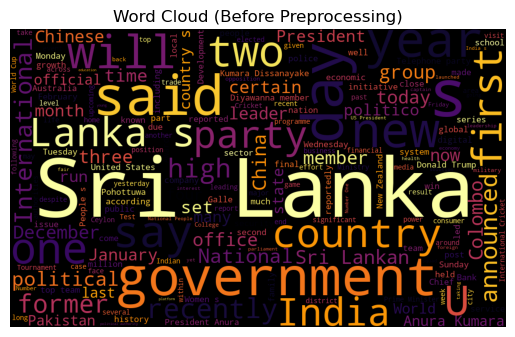

In [11]:
# Word Cloud 
# Combine all text data from the 'content' column into one large string. 
text = " ".join(all_news_df["content"].astype(str))

# Generating a visual representation of word frequencies
wordcloud = WordCloud(width=1000, height=600, colormap="inferno").generate(text)

# Rendering the plot using matplotlib features
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud (Before Preprocessing)")
plt.show()

According to the above wordcloud, the most visible words are,
 * Governemnet
 * Sri Lanka
 * Year
 * Country
 * Say
 * Party
  
Therefore, it can be concluded that the corpus mostly revolves around Sri Lanka and politics. However, the prominence of words like 'much', 'many', 'say', 'now'...etc can be directly attributed to preprocessing steps not being performed. This justifies the need for preprocessing steps such as stopword removal and lemmatization to enhance the quality of the dataset for model building.

### N-Grams (Unigram, Bigram, Trigram)
Unigrams show the most frequent/common individual words  
Bigrams show the most common 2-word phrases  
Trigrams show the most common 3-word phrases

In [12]:
# Unigram
# Converting text into a bag-of-words
vectorizer = CountVectorizer()  # default = unigrams

# Fit the vectorizer to the 'content' column of all_news_df and transform the text into a sparse matrix
# Each row = a document/news article
# Each column = a unique word from the corpus
X = vectorizer.fit_transform(all_news_df["content"].astype(str))

# Getting the total frequency of each word in the entire dataset
sum_words = X.sum(axis=0)

# vectorizer.vocabulary_ maps each word to its column index in X
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
# Sort the list of words in the descending order
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# Print the top 10 most frequent words in the dataset
print(words_freq[:10])

[('the', np.int64(2317)), ('of', np.int64(1022)), ('to', np.int64(968)), ('in', np.int64(878)), ('and', np.int64(666)), ('on', np.int64(338)), ('for', np.int64(333)), ('sri', np.int64(310)), ('is', np.int64(304)), ('has', np.int64(289))]


In [13]:
# Bigram
# consider sequences of exactly 2 consecutive words
vectorizer = CountVectorizer(ngram_range=(2,2))
X = vectorizer.fit_transform(all_news_df["content"].astype(str))

sum_words = X.sum(axis=0)

bigrams = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
bigrams = sorted(bigrams, key=lambda x: x[1], reverse=True)

print(bigrams[:10])

[('of the', np.int64(280)), ('sri lanka', np.int64(270)), ('in the', np.int64(255)), ('to the', np.int64(121)), ('for the', np.int64(104)), ('at the', np.int64(101)), ('to be', np.int64(87)), ('with the', np.int64(86)), ('on the', np.int64(75)), ('the country', np.int64(65))]


In [14]:
# Trigram
# consider sequences of exactly 3 consecutive words
vectorizer = CountVectorizer(ngram_range=(3,3))
X = vectorizer.fit_transform(all_news_df["content"].astype(str))

sum_words = X.sum(axis=0)

bigrams = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
bigrams = sorted(bigrams, key=lambda x: x[1], reverse=True)

print(bigrams[:10])

[('said to be', np.int64(48)), ('in sri lanka', np.int64(44)), ('is said to', np.int64(33)), ('of sri lanka', np.int64(31)), ('the sri lanka', np.int64(28)), ('anura kumara dissanayake', np.int64(27)), ('president anura kumara', np.int64(23)), ('the telephone party', np.int64(21)), ('one of the', np.int64(20)), ('are said to', np.int64(20))]


The unigram, bigram and the trigram yielded non-informative words/phrases to be most occurring. This again justifies the need for stopword removal as a preprocessing step.

### Text Length Distribution
Shows how long each text entry is (e.g., number of characters or words) across the dataset.

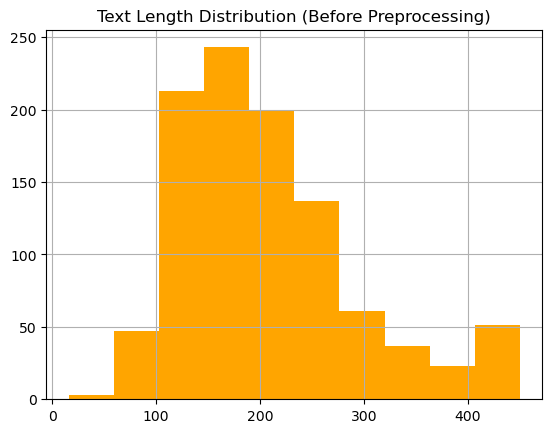

In [15]:
# Text Length Distribution
# Making a copy of the original dataset to keep the original data intact
all_news_1_df = all_news_df.copy()

# Create a new column 'text_length' that stores the number of characters in each article
all_news_1_df["text_length"] = all_news_df["content"].astype(str).apply(len)

# Plot a histogram of text lengths to visualize their distribution
all_news_1_df["text_length"].hist(color="orange")
plt.title("Text Length Distribution (Before Preprocessing)")
plt.show()

According to the above Text length Distribution histogram it can be seen that most of the articles have a length of 100-200 characters while there are about 50 longer articles with 400+ characters.

### Mean Text Length by Class
Shows the mean length of an article under each news category.

In [16]:
# Mean Text Length by Class
all_news_1_df.groupby("Class")["text_length"].mean()

Class
Business     217.177885
Opinion      248.475962
Political    183.288462
Sports       182.033149
World        203.604762
Name: text_length, dtype: float64

Personal Views or Opinion Related News articles are longer on average compared to the other news classes.

### Top Words Bar Graph
Top 10 words that appear the most in the corpus

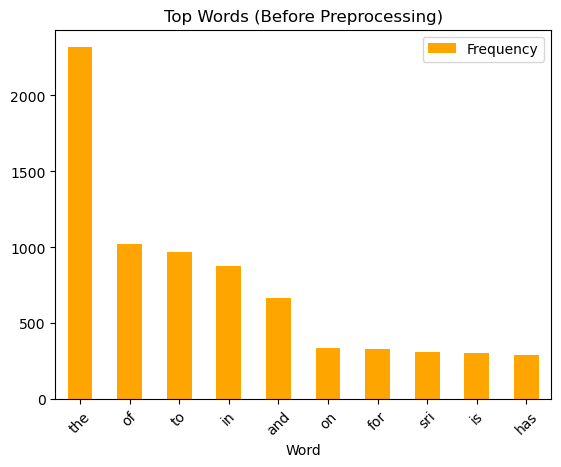

In [17]:
# Words that occur the most
# Select the top 10 most frequent words from the words_freq list
top_words = words_freq[:10]
df_words = pd.DataFrame(top_words, columns=["Word", "Frequency"])

# Create a bar chart of the top words
df_words.plot(x="Word", y="Frequency", kind="bar", color="orange")
plt.title("Top Words (Before Preprocessing)")
plt.xticks(rotation=45)
plt.show()

The above bar graph shows the most frequent 10 words in the corpus. Thus it is evident that non-informative words like conjunctions and prepositions dominate the corpus before preprocessing hinting at a vital requirement of stopword removal.

### Text Preprocessing

In [18]:
# Reading the excel into a new variable to proceed with preprocessing while the original file is kept intact
preprocess = pd.read_excel("Data/Data/Daily_Mirror_News.xlsx")

In [19]:
# display a single text record at 3rd index
preprocess.iloc[2]

content    As artificial intelligence (AI) evolves from b...
Class                                               Business
Name: 2, dtype: object

#### 1. Lowercasing 

In [20]:
preprocess["cleaned_content"] = preprocess["content"].str.lower()
preprocess.iloc[2]

content            As artificial intelligence (AI) evolves from b...
Class                                                       Business
cleaned_content    as artificial intelligence (ai) evolves from b...
Name: 2, dtype: object

In [21]:
preprocess["cleaned_content"] = preprocess["cleaned_content"].str.strip()
preprocess.iloc[2]


content            As artificial intelligence (AI) evolves from b...
Class                                                       Business
cleaned_content    as artificial intelligence (ai) evolves from b...
Name: 2, dtype: object

##### *Justification For Lowercasing*
Lowercasing ensures that words like “Business” and “business” are treated as the same term, improving consistency in analysis.

#### 2. Punctuation Removal

In [22]:
# observe the punctuations in the string library
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [23]:
# punctuations to be removed

# define the function
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation)) # remove all the punctuations

# applying the function
preprocess["cleaned_content"] = preprocess["cleaned_content"].apply(remove_punctuation)
preprocess.iloc[2]

content            As artificial intelligence (AI) evolves from b...
Class                                                       Business
cleaned_content    as artificial intelligence ai evolves from bei...
Name: 2, dtype: object

##### *Justification For Punctuation Removal*
Punctuation is removed because they would not add an additional meaning to the context and would also interfere with the potential analysis.

#### 3. Stopword Removal

In [24]:
# Get the list of stop words
stop_words = set(stopwords.words('english'))
print(stop_words)

{'an', 'doesn', 'mustn', 'their', 'her', 'our', 'were', 't', 'during', 'hasn', 'whom', 'no', 'because', 'needn', 'y', 'hers', 'where', "isn't", 'very', 'll', 'my', 'of', 'weren', 'your', 'was', 'themselves', 'doing', 'has', 'more', 'being', "it'd", 'shan', 'there', 'ain', 'herself', 'be', 'mightn', 'how', "hasn't", 'don', 'between', 'below', "needn't", 'yourselves', 'to', "don't", 'when', 'the', 'haven', 'so', 'own', 'in', "aren't", 'will', 'further', 'against', 'them', "it'll", 'just', "it's", 'won', "should've", 'off', 'again', 'this', 'a', 'at', 'why', 'these', 'only', 'himself', 'by', 'few', 'as', 'am', "weren't", "they'll", 'myself', 'such', 'above', "couldn't", 'his', 'through', 'once', 'isn', 'what', 're', 'down', "we'd", "i'd", 'while', 'now', 'did', 's', 'for', 'aren', "wouldn't", 'been', "shan't", 'you', "we've", 'but', 'is', "mightn't", "she'll", "you'd", 'it', "i've", 'ourselves', 'itself', 'ma', "they've", 'having', "they'd", 'o', 'that', 'she', "that'll", 'under', 'had', 

In [25]:
# define the function
def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in stop_words])

# apply the function
preprocess["cleaned_content"] = preprocess["cleaned_content"].apply(lambda text: remove_stopwords(text))
preprocess.iloc[2]

content            As artificial intelligence (AI) evolves from b...
Class                                                       Business
cleaned_content    artificial intelligence ai evolves technologic...
Name: 2, dtype: object

#### 4. Special Characters and Numbers Removal

In [26]:
# define the function
def remove_special_characters(text):
    return re.sub(r'[^A-Za-z\s]', '', text)

# apply the function
preprocess["cleaned_content"] = preprocess["cleaned_content"].apply(lambda text: remove_special_characters(text))
preprocess.iloc[235]

content            As we celebrated 77 years of independence yest...
Class                                                        Opinion
cleaned_content    celebrated  years independence yesterday line ...
Name: 235, dtype: object

##### *Justification For Special Characters and Numbers Removal*
They would not add an additional meaning to the context and would also interfere with the potential analysis.

#### 5. Common Words Removal

In [27]:
# Get the count of each word in cleaned_text
word_count = Counter(preprocess["cleaned_content"].str.split(expand=True).stack())

In [28]:
# Define a threshold for common words
n_common_words = 10
# Get a set of common words
common_words = set([word for (word,count) in word_count.most_common(n_common_words)])
print(common_words)

{'president', 'said', 'us', 'lanka', 'one', 'party', 'government', 'national', 'new', 'sri'}


In [29]:
# define the function
def remove_common_words(text):
    return " ".join([word for word in str(text).split() if word not in common_words])

# apply the function
preprocess["cleaned_content"] = preprocess["cleaned_content"].apply(lambda text: remove_common_words(text))
preprocess.iloc[287]

content            The NPP government’s ‘Clean Sri Lanka’ campaig...
Class                                                        Opinion
cleaned_content    npp governments clean campaign already receive...
Name: 287, dtype: object

##### *Justification For Common Words Removal*
Removal of common words that are highly frequent but less informative would improve the quality of potential text analysis by highlighting more distinctive and meaningful words.

#### 6. Rare words Removal

In [30]:
# Define a threshold for rare words
n_rare_words = 50
# Get a set of rare words
rare_words = set([word for (word,count) in word_count.most_common()[:-n_rare_words-1:-1]])
print(rare_words)

{'lower', 'collapsed', 'tribes', 'cheers', 'compromising', 'resign', 'divert', 'festejo', 'perus', 'congo', 'impeachment', 'promoted', 'sensitive', 'symptoms', 'crowds', 'sympathizing', 'bracing', 'consent', 'waterways', 'paralyzing', 'dances', 'levied', 'telecommunications', 'headed', 'coordination', 'usbacked', 'huacunda', 'southwestern', 'reverse', 'withdrew', 'bitcoin', 'fourthlargest', 'thessaloniki', 'eleventh', 'colorful', 'voa', 'shipping', 'oust', 'antistate', 'campaigns', 'noteria', 'angola', 'dramatically', 'khyber', 'penalties', 'flulike', 'clashes', 'scientific', 'pakhtunkhwas', 'entrepreneurship'}


In [31]:
# initial text
preprocess["cleaned_content"].iloc[1003]

'strengthening bilateral cooperation greece india cuttingedge research issues promoted scientific dialogue started thessaloniki nd international conference greece india history society science entrepreneurship'

In [32]:
# define the function
def remove_rare_words(text):
    return " ".join([word for word in str(text).split() if word not in rare_words])

preprocess["cleaned_content"] = preprocess["cleaned_content"].apply(lambda text: remove_rare_words(text))
preprocess["cleaned_content"].iloc[1003]

'strengthening bilateral cooperation greece india cuttingedge research issues dialogue started nd international conference greece india history society science'

##### *Justification For Rare Words Removal*
Rare words often would not significantly contribute meaningful patterns for text analysis as they occur only a very few times. By dropping these rare terms, we can focus more on informative words.

In [33]:
# initial text
preprocess['cleaned_content'].iloc[8]

'celebration world education day empire teas pvtltd reaffirms strong commitment nurturing young minds fostering leadership located kelanimulla angoda company remains dedicated shaping brighter promising future next generation'

In [34]:
# nltk.download('punkt_tab')

#### 7. Tokenization

In [35]:
preprocess['tokenized_content'] = preprocess['cleaned_content'].apply(lambda text: nltk.word_tokenize(text))
# tokenized text
preprocess['tokenized_content'].iloc[2]

['artificial',
 'intelligence',
 'ai',
 'evolves',
 'technological',
 'buzzword',
 'business',
 'imperative',
 'recent',
 'study',
 'commissioned',
 'microsoft',
 'international',
 'data',
 'corporation',
 'idc',
 'titled',
 'the',
 'business',
 'opportunity',
 'ai',
 'reveals',
 'crucial',
 'shift',
 'businesses',
 'longer',
 'asking',
 'integrate',
 'ai',
 'rather',
 'strategically',
 'gain',
 'competitive',
 'edge']

##### *Justification For Tokenization*
Tokenization splits the text into individual words (tokens), making it easier to analyze and process text data.

In [36]:
# lookup a word
wordnet.synsets('looking')

[Synset('look.n.02'),
 Synset('looking.n.02'),
 Synset('look.v.01'),
 Synset('look.v.02'),
 Synset('look.v.03'),
 Synset('search.v.02'),
 Synset('front.v.01'),
 Synset('attend.v.02'),
 Synset('look.v.07'),
 Synset('expect.v.03'),
 Synset('look.v.09'),
 Synset('count.v.08'),
 Synset('looking.s.01')]

In [37]:
# nltk.download('averaged_perceptron_tagger_eng')

#### 8. Lemmatization

In [38]:
# initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# mapping for word types
wordnet_map = {"N":wordnet.NOUN,'V':wordnet.VERB,'J':wordnet.ADJ,'R':wordnet.ADV}

# define the function
def lemmatize_tokens(tokens):
    lemmas = []
    for token in tokens:
        pos_tag = nltk.pos_tag([token])[0][1][0].upper()  # Get the POS tag
        lemma = lemmatizer.lemmatize(token, wordnet_map.get(pos_tag, wordnet.NOUN))  # Lemmatize with the appropriate POS tag
        lemmas.append(lemma)
    return lemmas


# applying the function
preprocess['lematized_content'] = preprocess['tokenized_content'].apply(lambda text: lemmatize_tokens(text))
preprocess[['tokenized_content','lematized_content']].tail(5)

,tokenized_content,lematized_content
1010,"[protesters, erupted, outside, south, koreas, ...","[protester, erupt, outside, south, korea, parl..."
1011,"[lankas, agency, responsible, countering, mone...","[lankas, agency, responsible, counter, money, ..."
1012,"[south, korean, yoon, suk, yeol, declared, eme...","[south, korean, yoon, suk, yeol, declare, emer..."
1013,"[french, prime, minister, michel, barnier, noc...","[french, prime, minister, michel, barnier, noc..."
1014,"[joe, biden, sunday, trip, deliver, promise, v...","[joe, biden, sunday, trip, deliver, promise, v..."


##### *Justification For Lemmatization*
Lemmatization reduces words to their base or root form (hosted-->host), helping to group similar words together and improve analysis accuracy..

#### 9. Spellchecking 

In [39]:
# initialize the spellchecker
spell = SpellChecker()

# define the function
def spell_check(text):
    words = text.split()
    checked_words = []
    for word in words:
        corrected_word = spell.correction(word)
        if corrected_word:
            checked_words.append(corrected_word)
        else:
            checked_words.append(word)  # If no correction found, keep the original word

    return ' '.join(checked_words)

In [40]:
# cleaned text
print(spell_check(preprocess['cleaned_content'].iloc[9]))

roared leading authority platform marketing launched first training initiative year advanced meta optimization workshop tailored ogilvy digital


##### *Justification For spellchecking*
Spelling errors were corrected to ensure consistency in the dataset, preventing the model from treating misspelled words as different features.

### Saving the Pre-processed file

In [41]:
# Copying only the lemmatized_content and Class into a new dataframe
model_df = preprocess[['lematized_content', 'Class']].copy()

# Converting lematized_content column from a list to string
model_df['lematized_content'] = model_df['lematized_content'].apply(lambda x: ' '.join(x))

# Saving the final file as ‘Preprocessed_Daily_Mirror_News.xlsx’
model_df.to_excel("Data/Data/Preprocessed_Daily_Mirror_News.xlsx", index=False)

### EDA after Preprocessing

#### Word Cloud

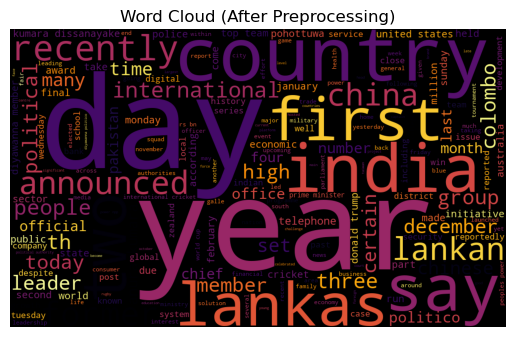

In [42]:
# Word Cloud 
# Combine all text data from the 'content' column into one large string
# This is required because WordCloud expects a single block of text
text = " ".join(preprocess["cleaned_content"].astype(str))

# Generating a visual representation of word frequencies
wordcloud = WordCloud(width=1000, height=600, colormap="inferno").generate(text)

# Rendering the plot using matplotlib features
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud (After Preprocessing)")
plt.show()

In the word cloud after preprocessing, we can see more significant and content-specific words such as country, india, year, group, chinese, and international, whereas before preprocessing, the word cloud had a lot of common less-meaningful words such as now, two, four, etc., which do not add much value. This suggests that the preprocessing was effective, as we can easily identify important topics such as politics, leadership, etc.

#### Bigram

In [43]:
# Bigram
# consider sequences of exactly 2 consecutive words
vectorizer = CountVectorizer(ngram_range=(2,2))
X = vectorizer.fit_transform(model_df["lematized_content"].astype(str))

sum_words = X.sum(axis=0)

bigrams = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
bigrams = sorted(bigrams, key=lambda x: x[1], reverse=True)

print(bigrams[:10])

[('anura kumara', np.int64(28)), ('donald trump', np.int64(27)), ('diyawanna member', np.int64(27)), ('kumara dissanayake', np.int64(24)), ('united state', np.int64(22)), ('top team', np.int64(22)), ('prime minister', np.int64(17)), ('international cricket', np.int64(17)), ('take place', np.int64(16)), ('people power', np.int64(16))]


Before preprocessing, the dominant bigrams were “of the,” “in the,” “on the,” etc., which are not very informative.

After the preprocessing steps, the bigrams are more informative, as seen below:
Anura Kumara – key political figure
Donald Trump, United State – international context
Prime Minister, People Power – political themes
International Cricket, Top Team – sports-related content

This shows that the preprocessing steps were effective in extracting context-rich phrases from the text data.

#### Text Length Distribution

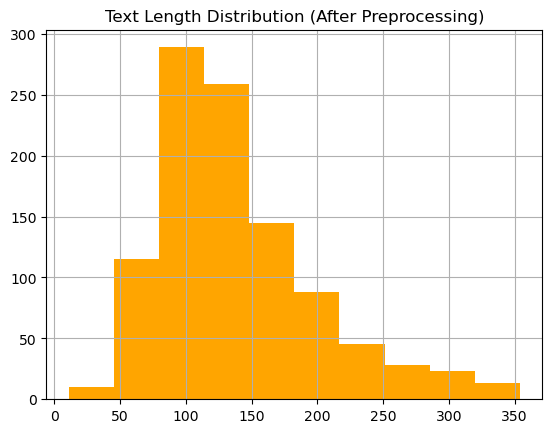

In [44]:
# Text Length Distribution
# Making a copy of the original dataset to keep the original data intact
model_1_df = model_df.copy()

# Create a new column 'text_length' that stores the number of characters in each article
model_1_df["text_length"] = model_df["lematized_content"].astype(str).apply(len)

# Plot a histogram of text lengths to visualize their distribution
model_1_df["text_length"].hist(color="orange")
plt.title("Text Length Distribution (After Preprocessing)")
plt.show()

Text Length has significantly reduced after the preprocessing steps as most frequent, less-meaningful words were removed from the records.

## Task 3: Selecting a Hugging Face Model

Selected model: distilbert/distilbert-base-uncased

We selected the DistilBERT model (distilbert-base-uncased) for this task because it provides an effective balance between performance and computational efficiency. DistilBERT is a distilled version of BERT, which retains most of BERT’s language understanding capabilities while being smaller and faster.

Since the dataset used in this assignment is relatively moderate in size, DistilBERT is well suited for training on a local machine without requiring high computational resources. It enables faster training and inference compared to larger models such as BERT and RoBERTa while still maintaining strong performance for text classification tasks.

Additionally, DistilBERT integrates seamlessly with the Hugging Face Transformers library, making it easy to fine-tune and deploy within a web application. Therefore, it is an appropriate choice for building an efficient and scalable news classification system.

## Task 4: Finetune a pre-trained Hugging Face Model

In [45]:
#Step 1: Load the preprocessed dataset
df = pd.read_excel("Data/Data/Preprocessed_Daily_Mirror_News.xlsx")
df.head()

,lematized_content,Class
0,lankas inflation expect increase sizeably thir...,Business
1,anura kumara dissanayake,Business
2,artificial intelligence ai evolves technologic...,Business
3,group ride ceylon participant uk canada recent...,Business
4,aspi close green result price gain counter cey...,Business


In [46]:
#Step 2: Encode labels 
le = LabelEncoder()
df["Class"] = le.fit_transform(df["Class"])
 
id_to_label = {
    0: "Business",
    1: "Opinion",
    2: "Political",
    3: "Sports",
    4: "World"
}

label_to_id = {
    "Business": 0,
    "Opinion": 1,
    "Political": 2,
    "Sports": 3,
    "World": 4
}
print(id_to_label)


{0: 'Business', 1: 'Opinion', 2: 'Political', 3: 'Sports', 4: 'World'}


In [47]:
#Step 3: train and validation split
X_train, X_val, y_train, y_val = train_test_split(
    df["lematized_content"],
    df["Class"],
    test_size=0.2,
    random_state=42,
    stratify=df["Class"]
)

In [48]:
#Step 4: Converting the original df to a data structure that is easy to handle using transformers
train_dataset = Dataset.from_dict({"text": list(X_train),"label": list(y_train)})

val_dataset = Dataset.from_dict({"text": list(X_val),"label": list(y_val)})

In [49]:
print(train_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 812
})


In [50]:
print(val_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 203
})


In [51]:
# Login to hugging face group account
login("YOUR_HUGGINGFACE_TOKEN_HERE")

In [52]:
# Step 5: Load tokenizer and model
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5,
    id2label=id_to_label,    
    label2id=label_to_id      
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [53]:
#Step 6: Tokenize the dataset
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/812 [00:00<?, ? examples/s]

Map:   0%|          | 0/203 [00:00<?, ? examples/s]

In [54]:
#Step 7: Evaluation metrics
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=p.label_ids)["accuracy"],
        "precision": precision_metric.compute(predictions=preds, references=p.label_ids, average="weighted")["precision"],
        "recall": recall_metric.compute(predictions=preds, references=p.label_ids, average="weighted")["recall"],
        "f1": f1_metric.compute(predictions=preds, references=p.label_ids, average="weighted")["f1"],
    }

Since our task involves classifying to five classes, we modified the evaluation metrics to use weighted averaging to correctly handle multi-class predictions.

In [55]:
#Step 8: Trainer setup

args = TrainingArguments(
    output_dir="Model_Output", # Directory where model checkpoints and outputs will be saved
    run_name="news_classifier", # Name of the training run
    eval_strategy="epoch",  # Evaluate the model after each full pass (epoch) through the dataset
    save_strategy="epoch",  # Save the model after each epoch 
    per_device_train_batch_size=4,  # Number of samples processed at once during training (smaller = less memory usage)
    per_device_eval_batch_size=4,   # Number of samples processed at once during evaluation
    num_train_epochs=3,           # Total number of times the model will see the entire dataset 
    learning_rate=2e-5,          # Controls how fast the model updates weights (optimal for BERT-based models)
    weight_decay=0.01,       #prevent overfitting
    logging_steps=50,        # Logs training progress every 50 steps
    seed=42,                # Ensures reproducibility of results (same random behavior each run)
    load_best_model_at_end=True   # Loads the best-performing model based on validation results
)

trainer = Trainer(
    model=model,   #The pre-trained DistilBERT model to be fine-tuned
    args=args,   
    train_dataset=tokenized_train_dataset,  # Tokenized dataset used for training the model
    eval_dataset=tokenized_val_dataset,  # Tokenized dataset used for evaluating model performance
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [56]:
# Step 9: Train the model
train_output = trainer.train()
print(train_output)

c:\Users\acer\anaconda3\envs\Sasbro\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.766105,0.568477,0.871921,0.877871,0.871921,0.872040
2,0.396311,0.418455,0.886700,0.890787,0.886700,0.883334
3,0.226922,0.416424,0.881773,0.882313,0.881773,0.881760


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\acer\anaconda3\envs\Sasbro\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\acer\anaconda3\envs\Sasbro\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=609, training_loss=0.5295418207281328, metrics={'train_runtime': 1167.871, 'train_samples_per_second': 2.086, 'train_steps_per_second': 0.521, 'total_flos': 80676961827840.0, 'train_loss': 0.5295418207281328, 'epoch': 3.0})


### Save model locally

In [57]:
# Login to Hugging Face
notebook_login()

# Save model and Tokenizer locally
trainer.save_model("news_model")
tokenizer.save_pretrained("news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('news_model\\tokenizer_config.json', 'news_model\\tokenizer.json')

### Push to Hugging Face hub

In [ ]:
model.push_to_hub("groupproj/group1-news-classifier-model")
tokenizer.push_to_hub("groupproj/group1-news-classifier-model")

README.md: 0.00B [00:00, ?B/s]

c:\Users\acer\anaconda3\envs\Sasbro\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\acer\.cache\huggingface\hub\models--groupproj--group1-news-classifier-model. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

### Test the finetuned model

In [ ]:
pipe = pipeline("text-classification", model="groupproj/group1-news-classifier-model")

pipe("Sri Lanka won the cricket match yesterday")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'Sports', 'score': 0.9824146628379822}]

In [ ]:
pipe("It is clear that the government needs to take stronger action to address corruption.")

[{'label': 'Opinion', 'score': 0.747744619846344}]

In [ ]:
pipe ("Sources say that a senior minister may soon resign due to internal party conflicts.")

[{'label': 'Political', 'score': 0.9203317165374756}]

In [ ]:
pipe("Stock market prices increased significantly due to strong investor confidence.")

[{'label': 'Business', 'score': 0.9693663120269775}]

### Link to the fine-tuned model pushed to hugging face 

https://huggingface.co/groupproj/group1-news-classifier-model